# `04 — Linearithmic sorting algorithms`

We study:
- **Merge Sort** (divide + merge)
- **Quick Sort** (partition around pivot)
- **Heap Sort** (using a heap as a black box — no heap internals)

Goal:
- Understand the *idea* and the *workflow*
- Know the **Big-O** (classic oral exam question)
- Be able to show step-by-step examples



## `1. Complexity summary`

| Algorithm | Best | Average | Worst | Extra memory | Stable? | Main idea |
|---|---:|---:|---:|---:|---:|---|
| **Merge sort** | O(N log N) | O(N log N) | O(N log N) | **O(N)** | **Yes** | split in halves + **merge in O(N)** |
| **Quick sort** | O(N log N) | O(N log N) | **O(N^2)** | O(log N) stack | Usually no | pick pivot + **partition** |
| **Heap sort** | O(N log N) | O(N log N) | O(N log N) | O(1) / O(N)* | No | build heap + extract repeatedly (heap as black box) |

\* In Python, using `heapq`, we use an auxiliary list (so practically O(N) memory).

## `2.1 Merge Sort — idea`

Merge sort uses **Divide and Conquer**:

1) **Divide** the array into two halves  
2) Recursively sort each half  
3) **Merge** the two sorted halves in **O(N)** time

**Key point:** merging two sorted arrays can be done in **linear time** by moving two pointers.
So:
- Each level of recursion costs **O(N)** total work (merging)
- Number of levels is **log₂ N**
=> total is **O(N log N)**

In [13]:
# Merge (two pointers) — code + trace:
from typing import List, Tuple, Self

def merge_two_sorted(a: List[int], b: List[int], *, verbose: bool = False) -> List[int]:
    i: int = 0
    j: int = 0
    out: List[int] = []

    if verbose:
        print(f" To merge a={a} and b={b}\n")

    while i < len(a) or j < len(b):
        if j >= len(b) or (i < len(a) and a[i] <= b[j]):
            out.append(a[i])
            i += 1
        else:
            out.append(b[j])
            j += 1

        if verbose:
            print("  ->", out)

    if verbose:
        print("\n Merged:", out, '\n', "-" * 55)
        
    return out


print("-" * 55)
print(f"{'Merge step demo in O(N)':^55}")
print("-" * 55)

out = merge_two_sorted([2, 4, 5, 7], [1, 3, 6, 8], verbose=True)

-------------------------------------------------------
                Merge step demo in O(N)                
-------------------------------------------------------
 To merge a=[2, 4, 5, 7] and b=[1, 3, 6, 8]

  -> [1]
  -> [1, 2]
  -> [1, 2, 3]
  -> [1, 2, 3, 4]
  -> [1, 2, 3, 4, 5]
  -> [1, 2, 3, 4, 5, 6]
  -> [1, 2, 3, 4, 5, 6, 7]
  -> [1, 2, 3, 4, 5, 6, 7, 8]

 Merged: [1, 2, 3, 4, 5, 6, 7, 8] 
 -------------------------------------------------------


In [15]:
# Merge Sort with “watch it evolve” tracing
from typing import List

def merge_sort_trace(x: List[int], *, depth: int = 0, verbose: bool = True) -> List[int]:
    indent: str = "   " * depth
    if verbose:
        print(f"{indent}merge_sort({x})")

    if len(x) <= 1:
        return x.copy()

    mid: int = len(x) // 2
    left: List[int] = merge_sort_trace(x[:mid], depth=depth + 1, verbose=verbose)
    right: List[int] = merge_sort_trace(x[mid:], depth=depth + 1, verbose=verbose)

    merged: List[int] = merge_two_sorted(left, right, verbose=False)

    if verbose:
        print(f"{indent}merge({left}, {right}) -> {merged}")

    return merged


print("-" * 55)
print(f"{'Merge Sort — Example 01 (random)':^55}")
print("-" * 55)

arr = [7, 5, 2, 4, 6, 3, 1, 8]
sorted_arr = merge_sort_trace(arr, verbose=True)
print("result:", sorted_arr)


-------------------------------------------------------
           Merge Sort — Example 01 (random)            
-------------------------------------------------------
merge_sort([7, 5, 2, 4, 6, 3, 1, 8])
   merge_sort([7, 5, 2, 4])
      merge_sort([7, 5])
         merge_sort([7])
         merge_sort([5])
      merge([7], [5]) -> [5, 7]
      merge_sort([2, 4])
         merge_sort([2])
         merge_sort([4])
      merge([2], [4]) -> [2, 4]
   merge([5, 7], [2, 4]) -> [2, 4, 5, 7]
   merge_sort([6, 3, 1, 8])
      merge_sort([6, 3])
         merge_sort([6])
         merge_sort([3])
      merge([6], [3]) -> [3, 6]
      merge_sort([1, 8])
         merge_sort([1])
         merge_sort([8])
      merge([1], [8]) -> [1, 8]
   merge([3, 6], [1, 8]) -> [1, 3, 6, 8]
merge([2, 4, 5, 7], [1, 3, 6, 8]) -> [1, 2, 3, 4, 5, 6, 7, 8]
result: [1, 2, 3, 4, 5, 6, 7, 8]


In [16]:
print("-" * 55)
print(f"{'Merge Sort — Example 02 (nearly sorted)':^55}")
print("-" * 55)

arr = [1, 2, 3, 4, 6, 5, 7, 8]
sorted_arr = merge_sort_trace(arr, verbose=True)
print("result:", sorted_arr)

-------------------------------------------------------
        Merge Sort — Example 02 (nearly sorted)        
-------------------------------------------------------
merge_sort([1, 2, 3, 4, 6, 5, 7, 8])
   merge_sort([1, 2, 3, 4])
      merge_sort([1, 2])
         merge_sort([1])
         merge_sort([2])
      merge([1], [2]) -> [1, 2]
      merge_sort([3, 4])
         merge_sort([3])
         merge_sort([4])
      merge([3], [4]) -> [3, 4]
   merge([1, 2], [3, 4]) -> [1, 2, 3, 4]
   merge_sort([6, 5, 7, 8])
      merge_sort([6, 5])
         merge_sort([6])
         merge_sort([5])
      merge([6], [5]) -> [5, 6]
      merge_sort([7, 8])
         merge_sort([7])
         merge_sort([8])
      merge([7], [8]) -> [7, 8]
   merge([5, 6], [7, 8]) -> [5, 6, 7, 8]
merge([1, 2, 3, 4], [5, 6, 7, 8]) -> [1, 2, 3, 4, 5, 6, 7, 8]
result: [1, 2, 3, 4, 5, 6, 7, 8]


## `3.1 Quick Sort — idea`

Quick sort also uses **Divide and Conquer**, but the “divide” step is different:

1) Choose a **pivot** (some element)
2) **Partition** the array into parts:
   - elements **< pivot**
   - elements **= pivot**
   - elements **> pivot**
3) Recursively sort the < and > parts

If partitions are balanced (about half/half):
- recursion depth ≈ log₂ N
- each partition step is O(N)
=> **O(N log N)**

But if pivot is always terrible (min or max):
- depth becomes N
- total becomes **O(N^2)**

In [ ]:
import random
from typing import List

def qsort_3way_trace(x: List[int], *, depth: int = 0, verbose: bool = True) -> List[int]:
    indent: str = "    " * depth
    if len(x) <= 1:
        if verbose:
            print(f"{indent}base: {x}")
        return x.copy()

    pivot: int = x[len(x) // 2]  # Deterministic pivot for reproducible trace.
    less: List[int] = []
    equal: List[int] = []
    greater: List[int] = []

    for v in x:
        if v < pivot:
            less.append(v)
        elif v > pivot:
            greater.append(v)
        else:
            equal.append(v)

    if verbose:
        print(f"{indent}qsort({x}) pivot={pivot}")
        print(f"{indent}  <  {less}")
        print(f"{indent}  =  {equal}")
        print(f"{indent}  >  {greater}")

    left_sorted: List[int] = qsort_3way_trace(less, depth=depth + 1, verbose=verbose)
    right_sorted: List[int] = qsort_3way_trace(greater, depth=depth + 1, verbose=verbose)

    merged: List[int] = left_sorted + equal + right_sorted
    if verbose:
        print(f"{indent}  -> {merged}")

    return merged


In [23]:
print("-" * 55)
print(f"{'Quick Sort — Example 01 (random)':^55}")
print("-" * 55)

arr = [7, 5, 2, 4, 6, 3, 1, 8]
print("result:", qsort_3way_trace(arr, verbose=True))

-------------------------------------------------------
           Quick Sort — Example 01 (random)            
-------------------------------------------------------
qsort([7, 5, 2, 4, 6, 3, 1, 8]) pivot=6
  <  [5, 2, 4, 3, 1]
  =  [6]
  >  [7, 8]
    qsort([5, 2, 4, 3, 1]) pivot=4
      <  [2, 3, 1]
      =  [4]
      >  [5]
        qsort([2, 3, 1]) pivot=3
          <  [2, 1]
          =  [3]
          >  []
            qsort([2, 1]) pivot=1
              <  []
              =  [1]
              >  [2]
                base: []
                base: [2]
              -> [1, 2]
            base: []
          -> [1, 2, 3]
        base: [5]
      -> [1, 2, 3, 4, 5]
    qsort([7, 8]) pivot=8
      <  [7]
      =  [8]
      >  []
        base: [7]
        base: []
      -> [7, 8]
  -> [1, 2, 3, 4, 5, 6, 7, 8]
result: [1, 2, 3, 4, 5, 6, 7, 8]


In [25]:
print("-" * 55)
print(f"{'Quick Sort — Example 02 (duplicates)':^55}")
print("-" * 55)

arr = [3, 5, 3, 2, 3, 8, 1, 3, 6]
print("result:", qsort_3way_trace(arr, verbose=True))


-------------------------------------------------------
         Quick Sort — Example 02 (duplicates)          
-------------------------------------------------------
qsort([3, 5, 3, 2, 3, 8, 1, 3, 6]) pivot=3
  <  [2, 1]
  =  [3, 3, 3, 3]
  >  [5, 8, 6]
    qsort([2, 1]) pivot=1
      <  []
      =  [1]
      >  [2]
        base: []
        base: [2]
      -> [1, 2]
    qsort([5, 8, 6]) pivot=8
      <  [5, 6]
      =  [8]
      >  []
        qsort([5, 6]) pivot=6
          <  [5]
          =  [6]
          >  []
            base: [5]
            base: []
          -> [5, 6]
        base: []
      -> [5, 6, 8]
  -> [1, 2, 3, 3, 3, 3, 5, 6, 8]
result: [1, 2, 3, 3, 3, 3, 5, 6, 8]


**Teaching takeaway:**
- The “magic” of Quick sort is the **partition** step.
- If pivot splits well, recursion height is **log N** → fast.
- If pivot splits badly every time, height is **N** → worst-case **O(N²)**.
- Random pivot selection is a common practical fix.


## `4.1 Heap Sort — idea (heap is a black box)`

Assume we have a data structure called a **heap** that supports:

- build_heap(array) in O(N)
- extract_min / extract_max in O(log N)
- (optionally) insert in O(log N)

Heap sort strategy:
1) Put all elements into a heap (build_heap)
2) Repeatedly extract the smallest (or largest) and append to output

Total:
- build: O(N)
- N extractions: N · O(log N) = O(N log N)

So overall: **O(N log N)**.

In [ ]:
import heapq
from typing import List

def heap_sort_blackbox(x: List[int], *, verbose: bool = True) -> List[int]:
    """
    Heap sort using heapq as a black box.
    We do NOT explain heap internals; we only use:
      - heapify: build heap
      - heappop: extract-min repeatedly
    """
    h: List[int] = x.copy()

    if verbose:
        print(f"start: {h}")

    heapq.heapify(h)
    if verbose:
        print(f"after heapify: {h}  (heap internal layout may look 'unsorted' — that's normal)")

    out: List[int] = []
    while h:
        out.append(heapq.heappop(h))
        if verbose:
            print(f"pop -> out={out}, heap_now={h}")

    return out


print("-" * 55)
print(f"{'Heap Sort — Example 01 (black box heap)':^55}")
print("-" * 55)

arr = [7, 5, 2, 4, 6, 3, 1, 8]
print("result:", heap_sort_blackbox(arr, verbose=True))


-------------------------------------------------------
        Heap Sort — Example 01 (black box heap)        
-------------------------------------------------------
start: [7, 5, 2, 4, 6, 3, 1, 8]
after heapify: [1, 4, 2, 5, 6, 3, 7, 8]  (heap internal layout may look 'unsorted' — that's normal)
pop -> out=[1], heap_now=[2, 4, 3, 5, 6, 8, 7]
pop -> out=[1, 2], heap_now=[3, 4, 7, 5, 6, 8]
pop -> out=[1, 2, 3], heap_now=[4, 5, 7, 8, 6]
pop -> out=[1, 2, 3, 4], heap_now=[5, 6, 7, 8]
pop -> out=[1, 2, 3, 4, 5], heap_now=[6, 8, 7]
pop -> out=[1, 2, 3, 4, 5, 6], heap_now=[7, 8]
pop -> out=[1, 2, 3, 4, 5, 6, 7], heap_now=[8]
pop -> out=[1, 2, 3, 4, 5, 6, 7, 8], heap_now=[]
result: [1, 2, 3, 4, 5, 6, 7, 8]


**Notes takeaway:**
- The heap array after `heapify` is **not sorted** — it only satisfies the **heap property** internally.
- Heap sort becomes sorted because we repeatedly take the **minimum element** out.
- We didn’t need to know the heap internals to reason about complexity:  
  **N extractions × O(log N) each → O(N log N)**.

----------------------------------------------------------------------
                Benchmark: n log n sorting algorithms                 
----------------------------------------------------------------------
n=1000
  Merge sort (O(n log n))              0.001225 s
  Quick sort 3-way (avg O(n log n))    0.000718 s
  Heap sort (O(n log n))               0.000107 s
  Python sorted() (TimSort)            0.000028 s

n=2000
  Merge sort (O(n log n))              0.002586 s
  Quick sort 3-way (avg O(n log n))    0.001546 s
  Heap sort (O(n log n))               0.000229 s
  Python sorted() (TimSort)            0.000068 s

n=4000
  Merge sort (O(n log n))              0.005603 s
  Quick sort 3-way (avg O(n log n))    0.003510 s
  Heap sort (O(n log n))               0.000528 s
  Python sorted() (TimSort)            0.000186 s

n=8000
  Merge sort (O(n log n))              0.011862 s
  Quick sort 3-way (avg O(n log n))    0.007365 s
  Heap sort (O(n log n))               0.001254 s
  Pyth

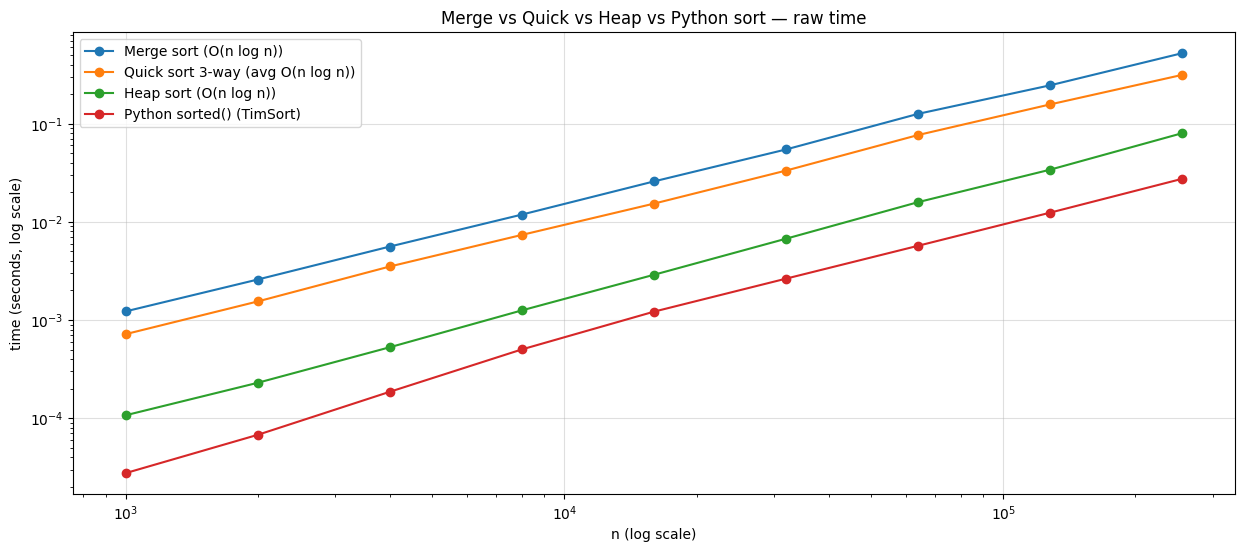

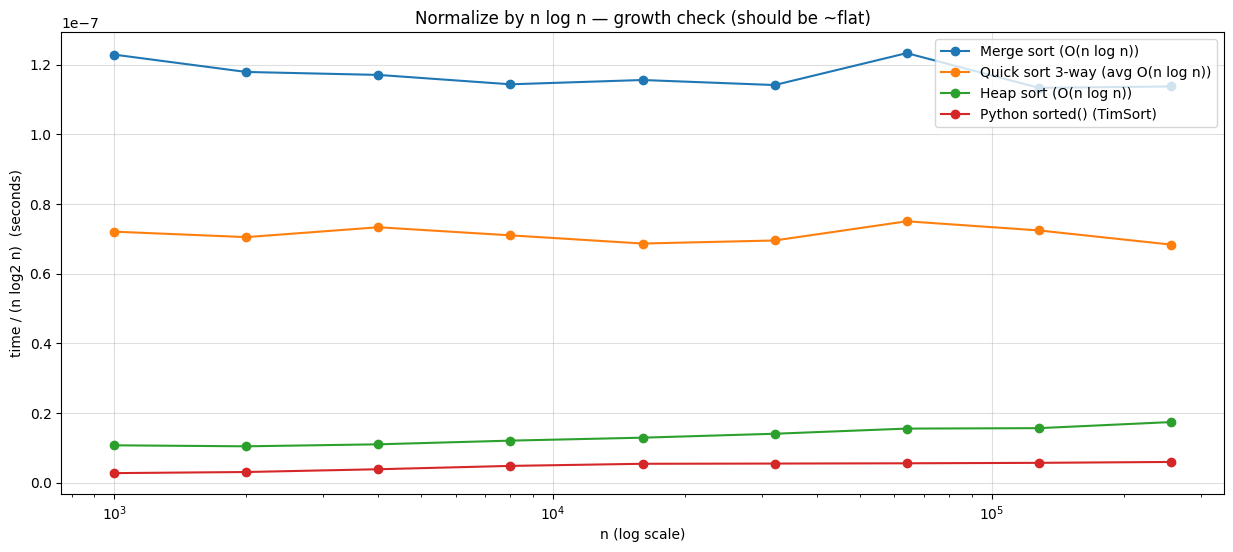


Notes takeaway:
• These all aim for ~O(n log n) behavior on typical inputs.
• Constant factors and Python overhead matter — that’s why the curves differ.
• Normalizing by n log n helps you 'see' whether growth is consistent with theory.


In [35]:
import time
import math
import heapq
import random
import matplotlib.pyplot as plt
from typing import Callable, Dict, List, Tuple


def merge_sort(x: List[int]) -> List[int]:
    if len(x) <= 1:
        return x.copy()
    mid = len(x) // 2
    left = merge_sort(x[:mid])
    right = merge_sort(x[mid:])
    return merge_two_sorted(left, right, verbose=False)

def qsort_3way(x: List[int]) -> List[int]:
    if len(x) <= 1:
        return x.copy()
    pivot = x[len(x) // 2]
    less = [v for v in x if v < pivot]
    equal = [v for v in x if v == pivot]
    greater = [v for v in x if v > pivot]
    return qsort_3way(less) + equal + qsort_3way(greater)

def heap_sort_blackbox_fast(x: List[int]) -> List[int]:
    h = x.copy()
    heapq.heapify(h)
    return [heapq.heappop(h) for _ in range(len(h))]

def time_call(fn: Callable[[], None], *, repeats: int) -> float:
    times: List[float] = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        fn()
        t1 = time.perf_counter()
        times.append(t1 - t0)
    times.sort()
    return times[len(times) // 2]


random.seed(7)

ns: List[int] = [1_000, 2_000, 4_000, 8_000, 16_000, 32_000, 64_000, 128_000, 256_000]
datasets: Dict[int, List[int]] = {n: [random.randint(0, 10_000_000) for _ in range(n)] for n in ns}

algs: List[Tuple[str, Callable[[List[int]], List[int]]]] = [
    ("Merge sort (O(n log n))", merge_sort),
    ("Quick sort 3-way (avg O(n log n))", qsort_3way),
    ("Heap sort (O(n log n))", heap_sort_blackbox_fast),
    ("Python sorted() (TimSort)", sorted),
]

results: Dict[str, List[float]] = {name: [] for name, _ in algs}

print("-" * 70)
print(f"{'Benchmark: n log n sorting algorithms':^70}")
print("-" * 70)

for n in ns:
    arr = datasets[n]
    print(f"n={n}")
    for name, alg in algs:
        elapsed = time_call(fn=lambda alg=alg, arr=arr: alg(arr), repeats=5)
        results[name].append(elapsed)
        print(f"  {name:<35}  {elapsed:.6f} s")
    print()
print('-' * 70)

# Plot 1: raw time (log-log)
plt.figure(figsize=(15, 6))
for name in results:
    plt.plot(ns, results[name], marker="o", label=name)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("n (log scale)")
plt.ylabel("time (seconds, log scale)")
plt.title("Merge vs Quick vs Heap vs Python sort — raw time")
plt.legend(); plt.grid(True, alpha=0.4)
plt.show()

# Plot 2: normalize by n log n (growth check)
plt.figure(figsize=(15, 6))
for name in results:
    normalized = [t / (n * math.log2(n)) for t, n in zip(results[name], ns)]
    plt.plot(ns, normalized, marker="o", label=name)
plt.xscale("log")
plt.xlabel("n (log scale)")
plt.ylabel("time / (n log2 n)  (seconds)")
plt.title("Normalize by n log n — growth check (should be ~flat)")
plt.legend(); plt.grid(True, alpha=0.4)
plt.show()

print("\nNotes takeaway:")
print("• These all aim for ~O(n log n) behavior on typical inputs.")
print("• Constant factors and Python overhead matter — that’s why the curves differ.")
print("• Normalizing by n log n helps you 'see' whether growth is consistent with theory.")